In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.model_selection import train_test_split

In [6]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
df.head()
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [9]:
features = ["pclass", "sex", "age", "embarked", "fare"]
target = ["survived"]

In [10]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [14]:
# missing data

from sklearn.impute import SimpleImputer 

imp_median = SimpleImputer(strategy="median")
df[["age"]] = imp_median.fit_transform(df[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
df[["embarked"]] = imp_freq.fit_transform(df[["embarked"]])


In [16]:
# encode
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])

In [17]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,2,Third,man,True,NaN,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,0,First,woman,False,C,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,2,Third,woman,False,NaN,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,2,First,woman,False,C,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,2,Third,man,True,NaN,Southampton,no,True


In [18]:
X = df[features]
y = df[target]

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [26]:
X_train.head()

,pclass,sex,age,embarked,fare
445,1,1,4.0,2,81.8583
650,3,1,28.0,2,7.8958
172,3,0,1.0,2,11.1333
450,2,1,36.0,2,27.7500
314,2,1,43.0,2,26.2500


In [27]:
# Decision Tree Model - no pruning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [28]:
y_pred = model.predict(X_test)

print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.7649253731343284


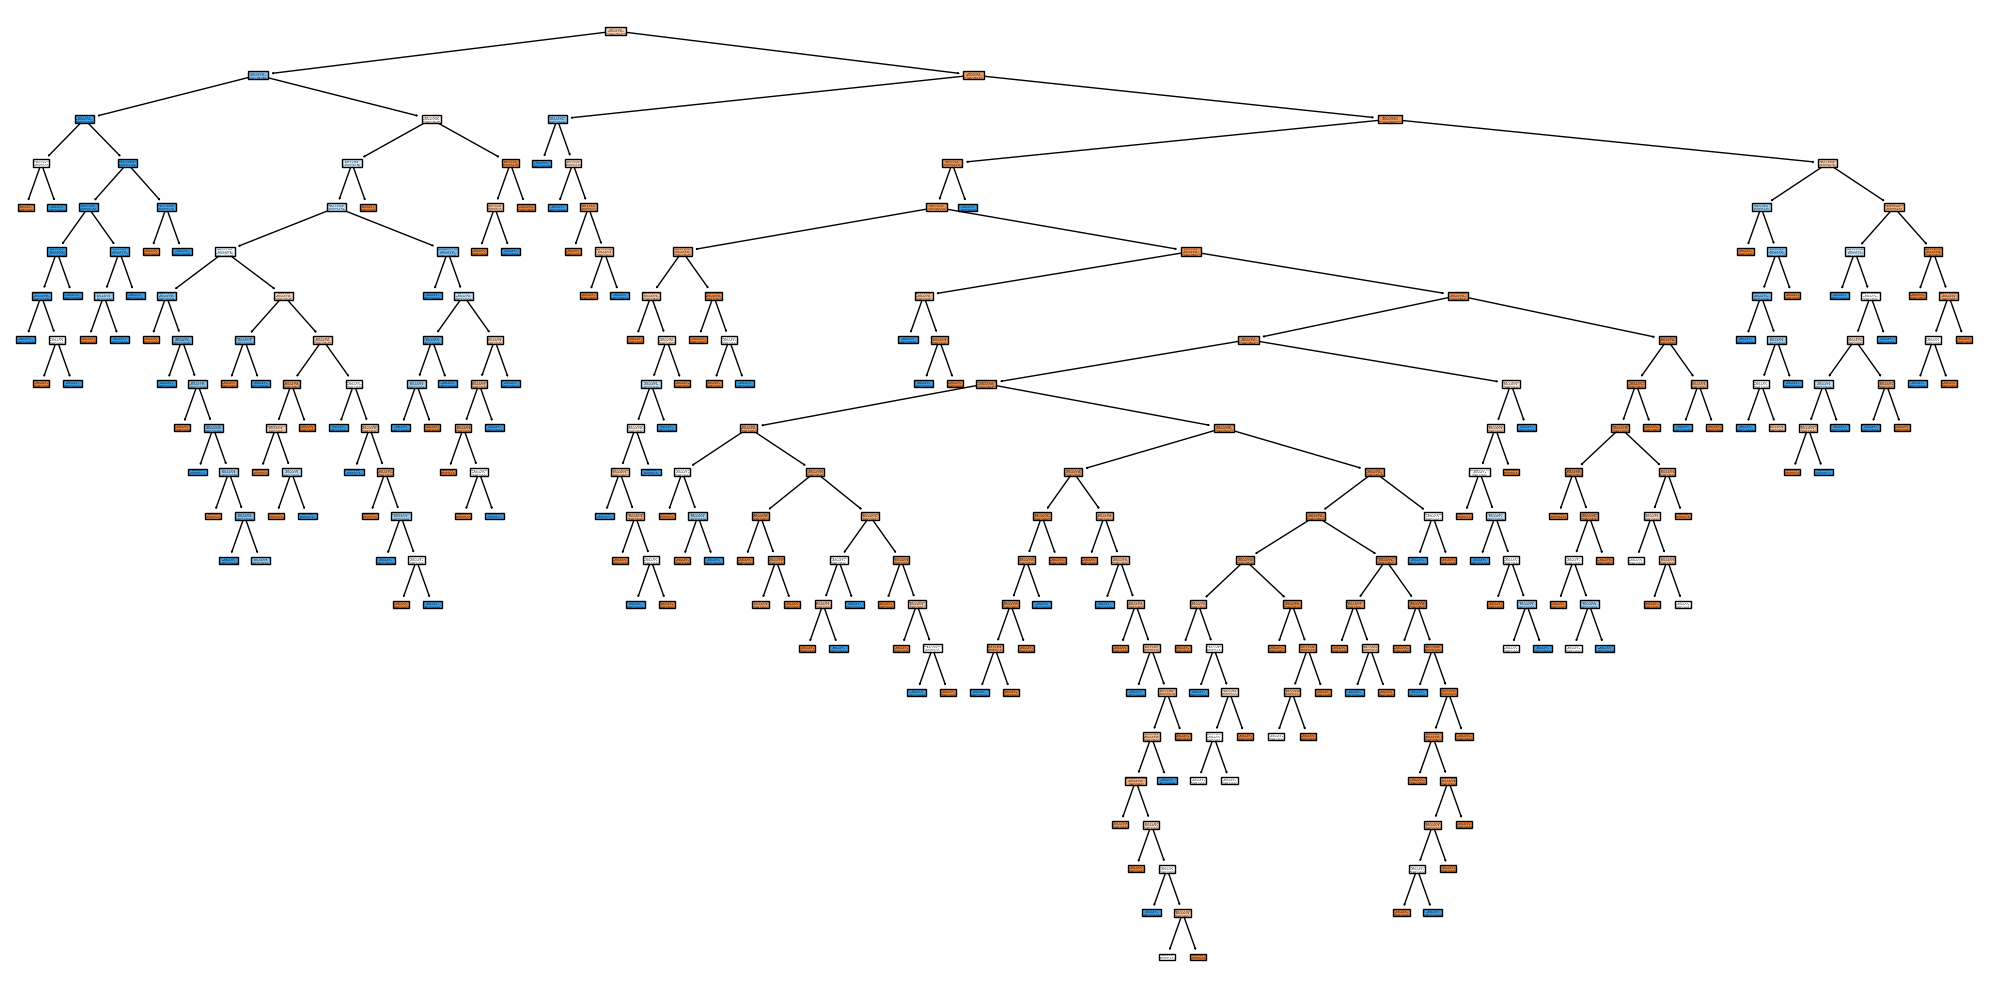

In [33]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model, 
    feature_names=X.columns,
    class_names=["Dies", "Survives"], # traget=0(died), 1(survived)
    filled=True,
)

plt.tight_layout()

plt.show()

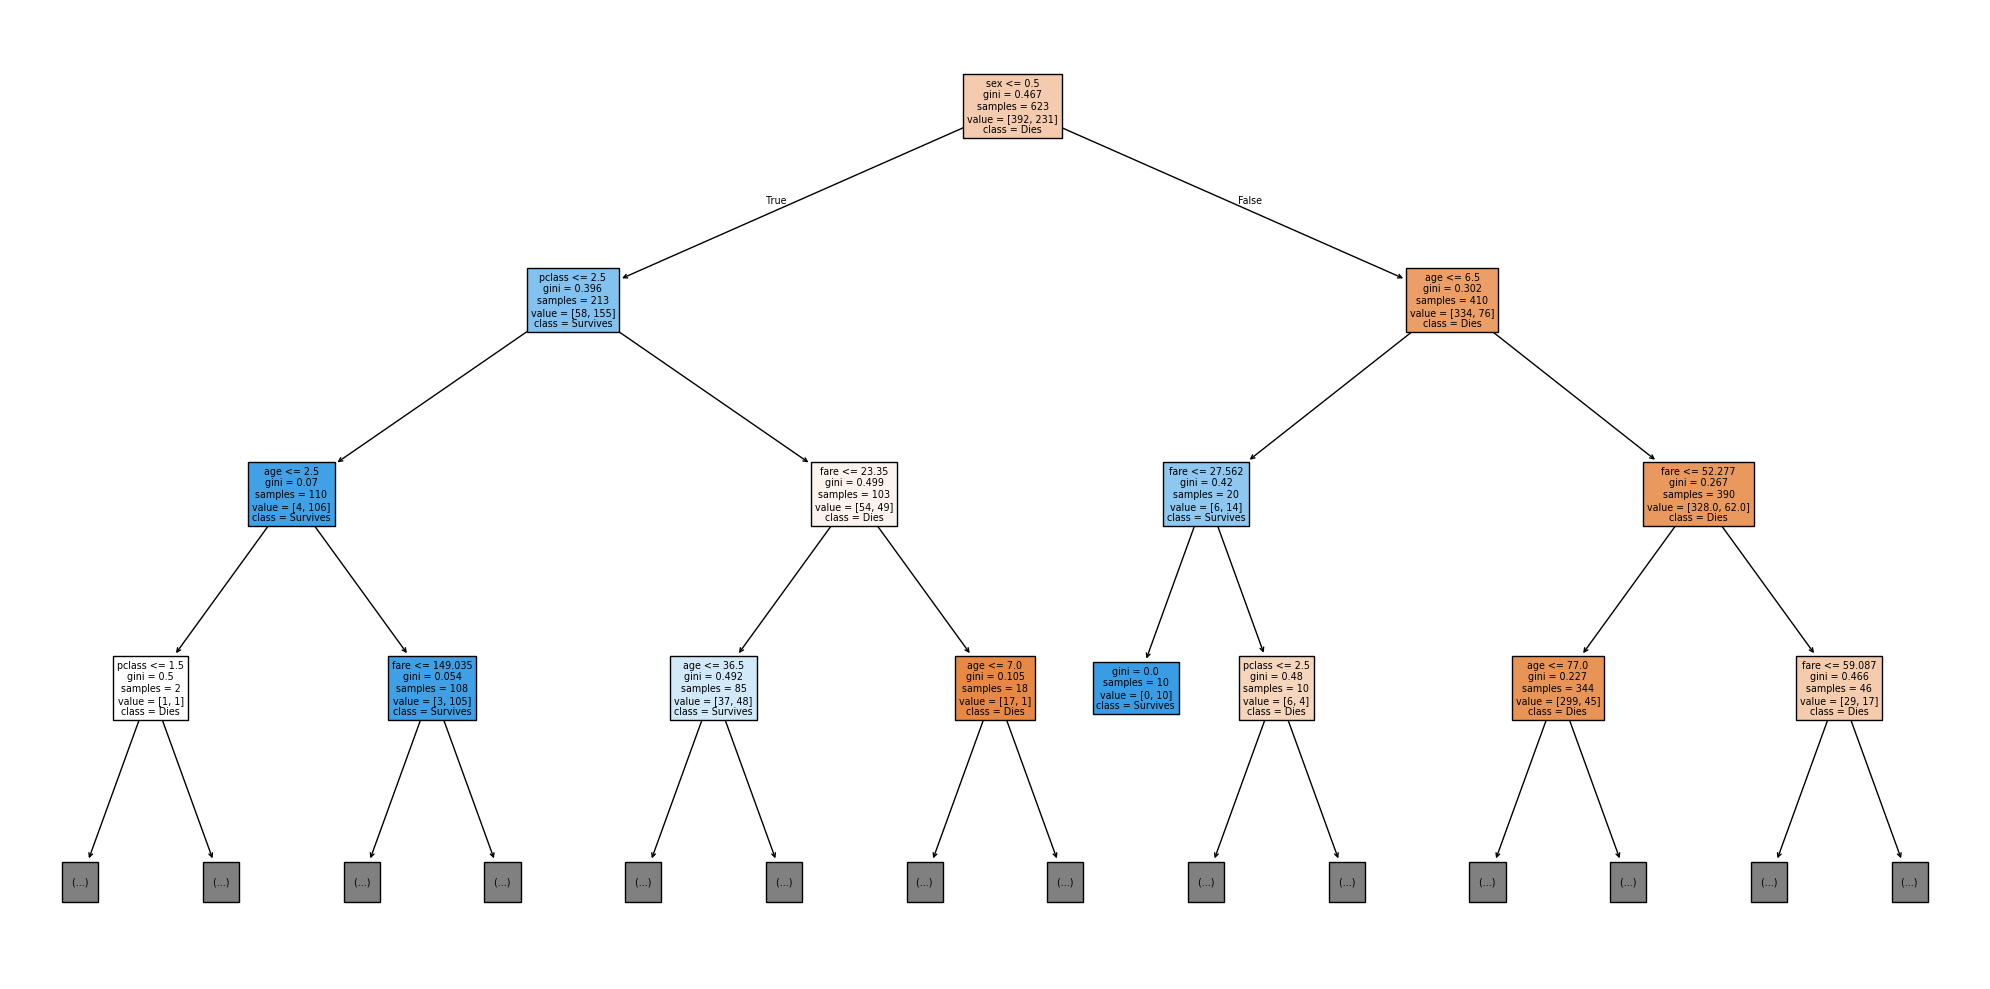

In [34]:
from sklearn.tree import plot_tree

# zommed image
plt.figure(figsize=(20, 10))

plot_tree(
    model, 
    feature_names=X.columns,
    class_names=["Dies", "Survives"], # traget=0(died), 1(survived)
    filled=True,
    max_depth=3
)

plt.tight_layout()

plt.show()

Accuracy: 0.7723880597014925 for depth = 2 

Accuracy: 0.8059701492537313 for depth = 3 

Accuracy: 0.8246268656716418 for depth = 4 



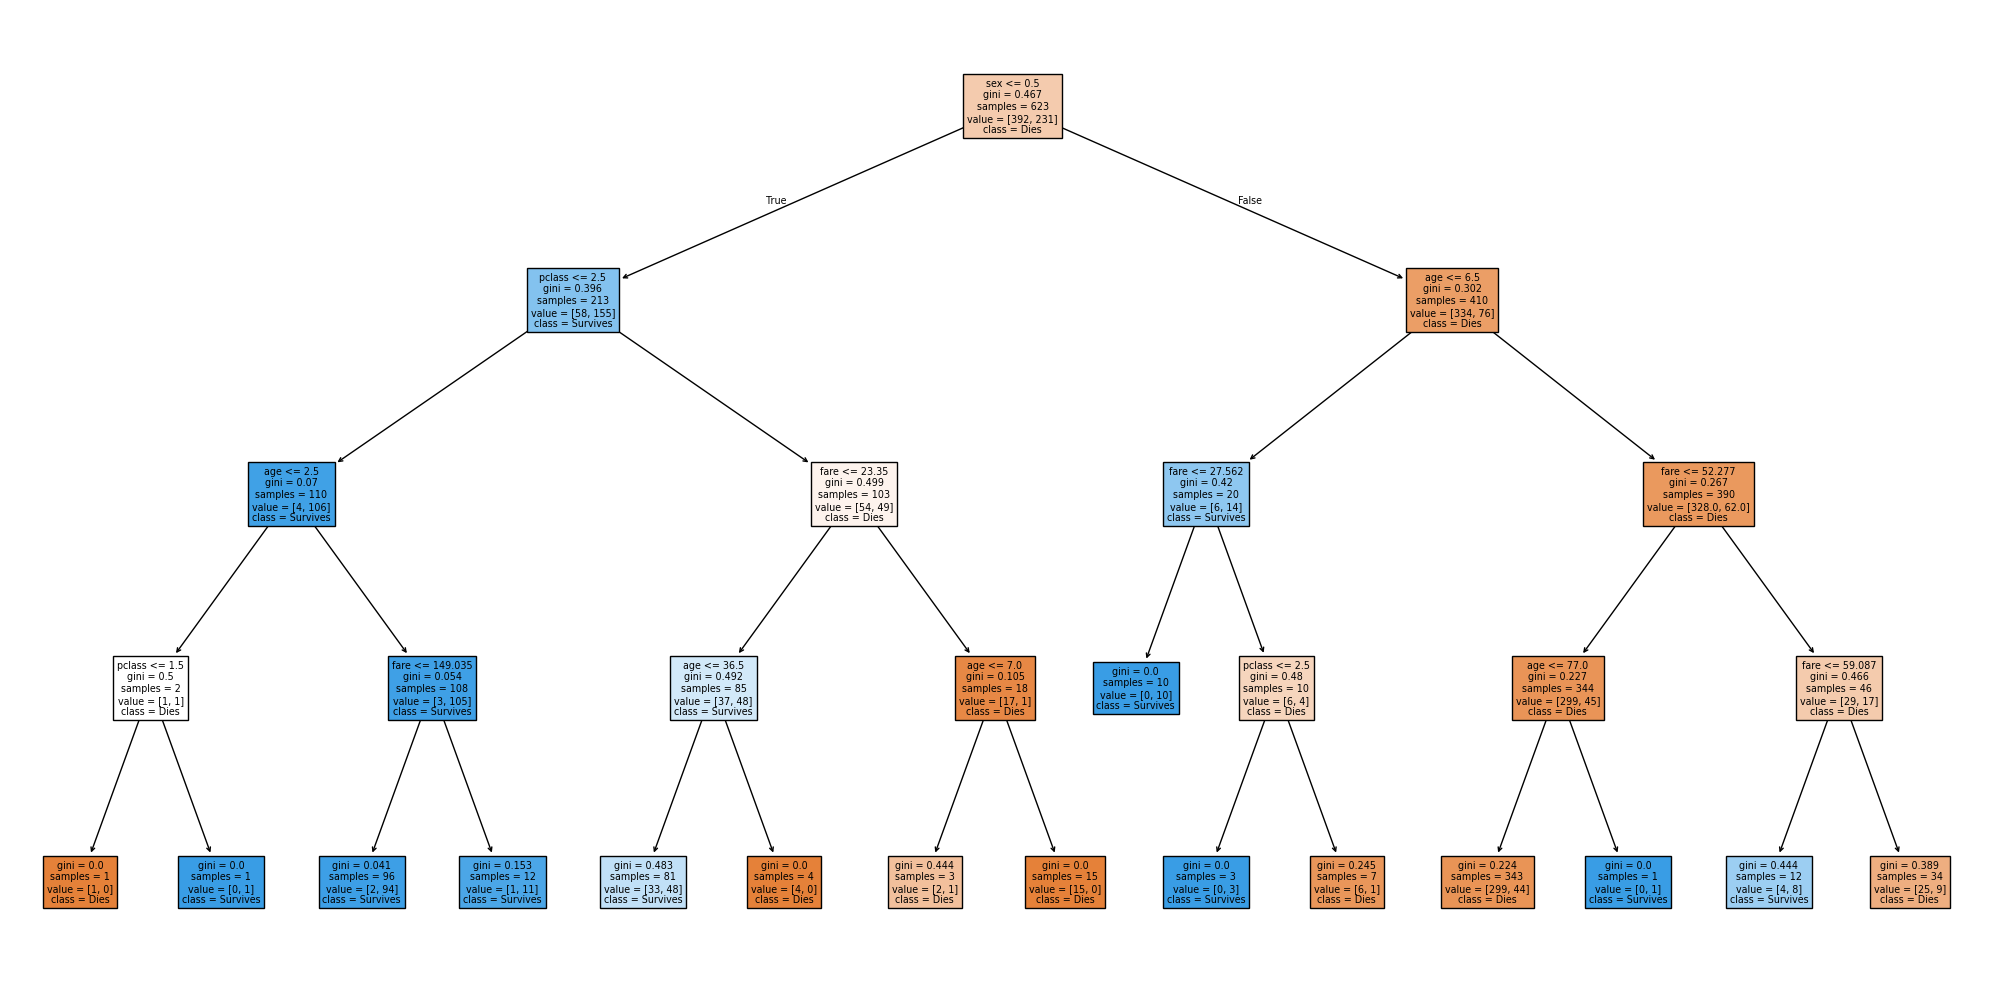

Accuracy: 0.7947761194029851 for depth = 5 

Accuracy: 0.7873134328358209 for depth = 6 

Accuracy: 0.7761194029850746 for depth = 7 

Accuracy: 0.8059701492537313 for depth = 8 

Accuracy: 0.7761194029850746 for depth = 9 

Accuracy: 0.7947761194029851 for depth = 10 



In [40]:
# Decision Tree with pre-preuning

max_depth = [2,3,4,5,6,7,8,9,10]

for depth in max_depth:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    print(f"Accuracy: {acc} for depth = {depth} \n")

    if depth==4:
        plt.figure(figsize=(20, 10))

        plot_tree(
            model, 
            feature_names=X.columns,
            class_names=["Dies", "Survives"], # traget=0(died), 1(survived)
            filled=True,
        )
        
        plt.tight_layout()
        
        plt.show()

        # when we cleared the with how much the max_depth we want then the tree is only made upto the max_depth after the pre-pruning

Accuracy: 0.8246268656716418 for split = 10 



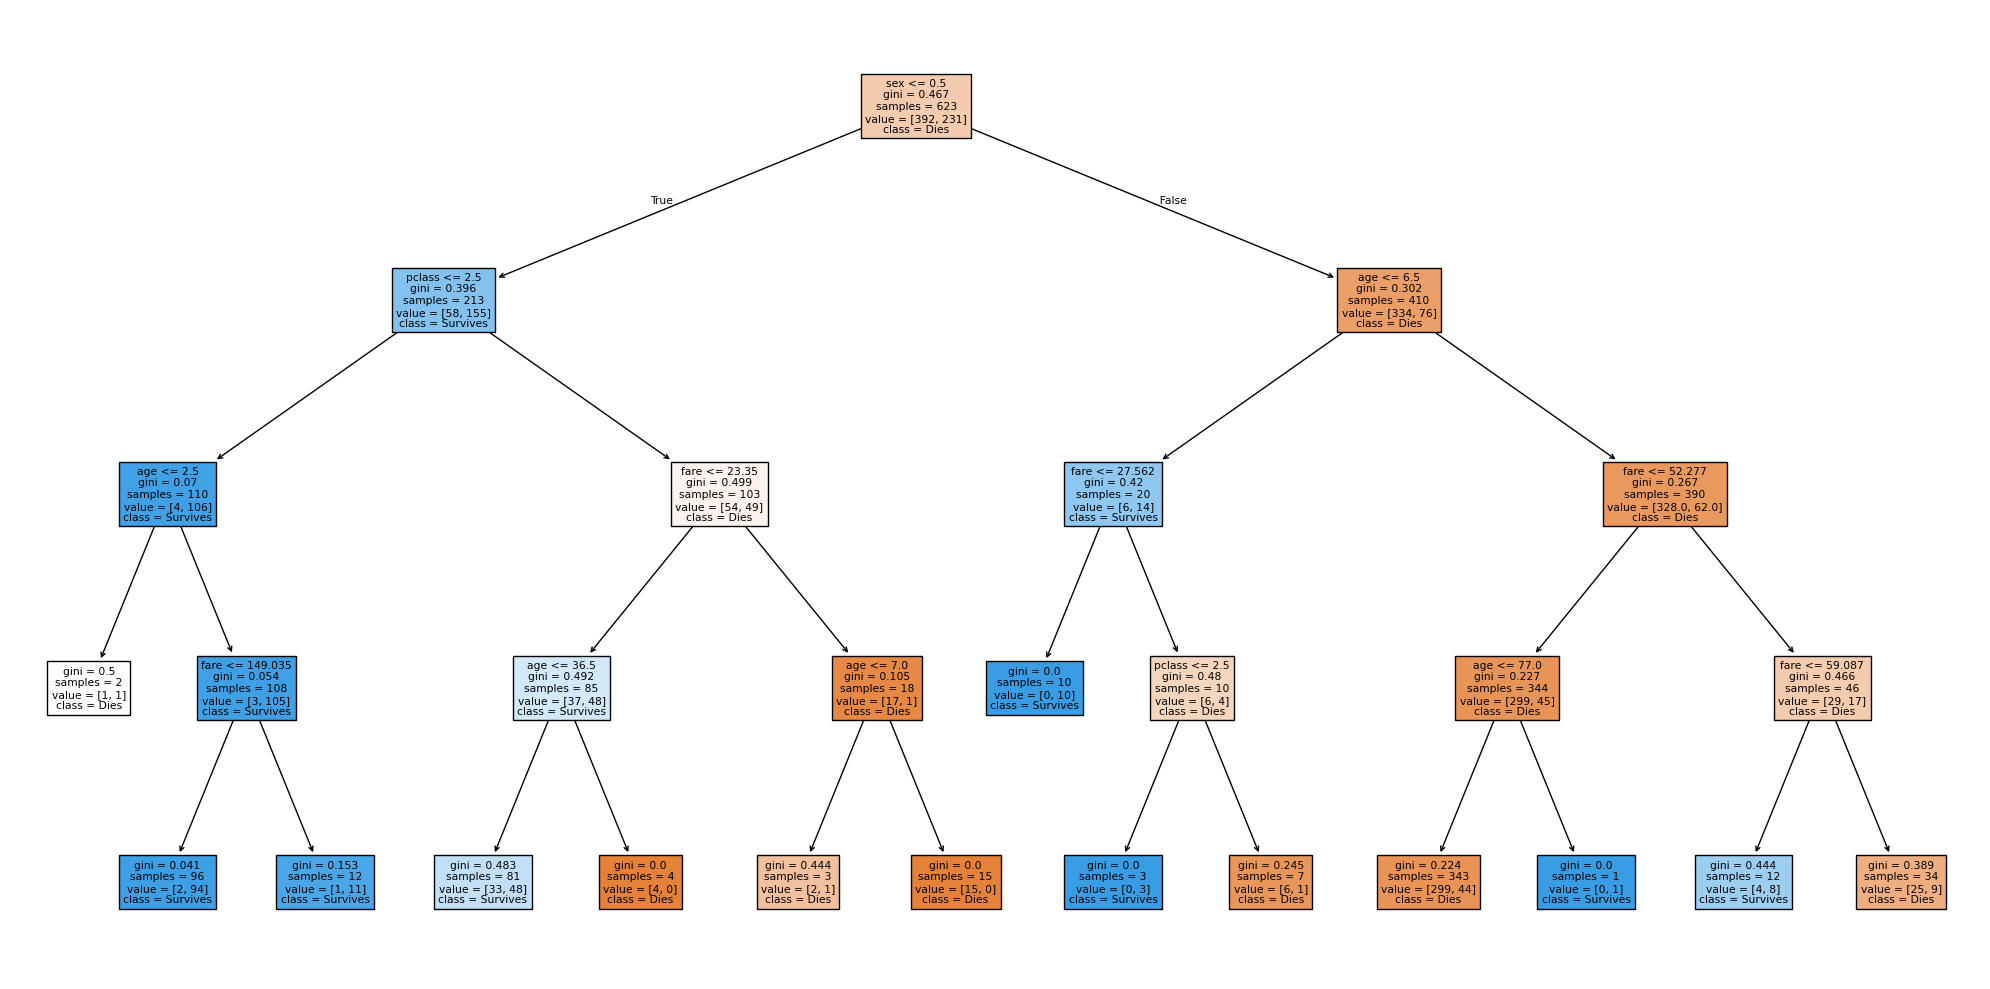

Accuracy: 0.8171641791044776 for split = 15 

Accuracy: 0.8171641791044776 for split = 20 

Accuracy: 0.8208955223880597 for split = 25 

Accuracy: 0.8208955223880597 for split = 30 



In [41]:
# Decision Tree with pre-preuning

min_sample_split = [10, 15, 20, 25, 30]

for split in min_sample_split:
    model = DecisionTreeClassifier(max_depth=4, min_samples_split=split)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    print(f"Accuracy: {acc} for split = {split} \n")
    
    if split==10:
        plt.figure(figsize=(20, 10))

        plot_tree(
            model, 
            feature_names=X.columns,
            class_names=["Dies", "Survives"], # traget=0(died), 1(survived)
            filled=True,
        )
        
        plt.tight_layout()
        
        plt.show()

In [42]:
# Decision Tree with Post-preuning 

full_tree = DecisionTreeClassifier(random_state=42)

full_tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
path = full_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

print(ccp_alphas)

[0.         0.         0.00013376 0.00013376 0.00022931 0.00032103
 0.00048409 0.00053505 0.00053505 0.00053505 0.00062746 0.00064205
 0.00077709 0.00085607 0.00093633 0.00096308 0.00096308 0.00096308
 0.00099875 0.00101659 0.00104193 0.0010478  0.00107009 0.00109238
 0.00115927 0.0012352  0.00123729 0.00129646 0.00132211 0.00133563
 0.00137583 0.00137583 0.00139708 0.00143228 0.00144145 0.00150482
 0.00151596 0.00152184 0.00171215 0.00183444 0.0019012  0.00195674
 0.00200642 0.00214018 0.00233474 0.0024077  0.00260835 0.00263292
 0.00278606 0.00280169 0.00284379 0.00288925 0.00299625 0.00302412
 0.00431144 0.00495299 0.00577849 0.00589431 0.0074248  0.01236198
 0.01787674 0.04065074 0.1323581 ]


In [47]:
# tain our model for all alphas

tree = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    tree.append((model, alpha))

In [49]:
best_acc = 0
best_alpha = 0

for model, alpha in tree:
    curr_acc = model.score(X_test, y_test)
    if curr_acc > best_acc:
        best_acc = curr_acc
        best_alpha = alpha

In [51]:
best_acc, best_alpha

(0.8208955223880597, np.float64(0.0017121455323702516))

In [53]:
best_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
best_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


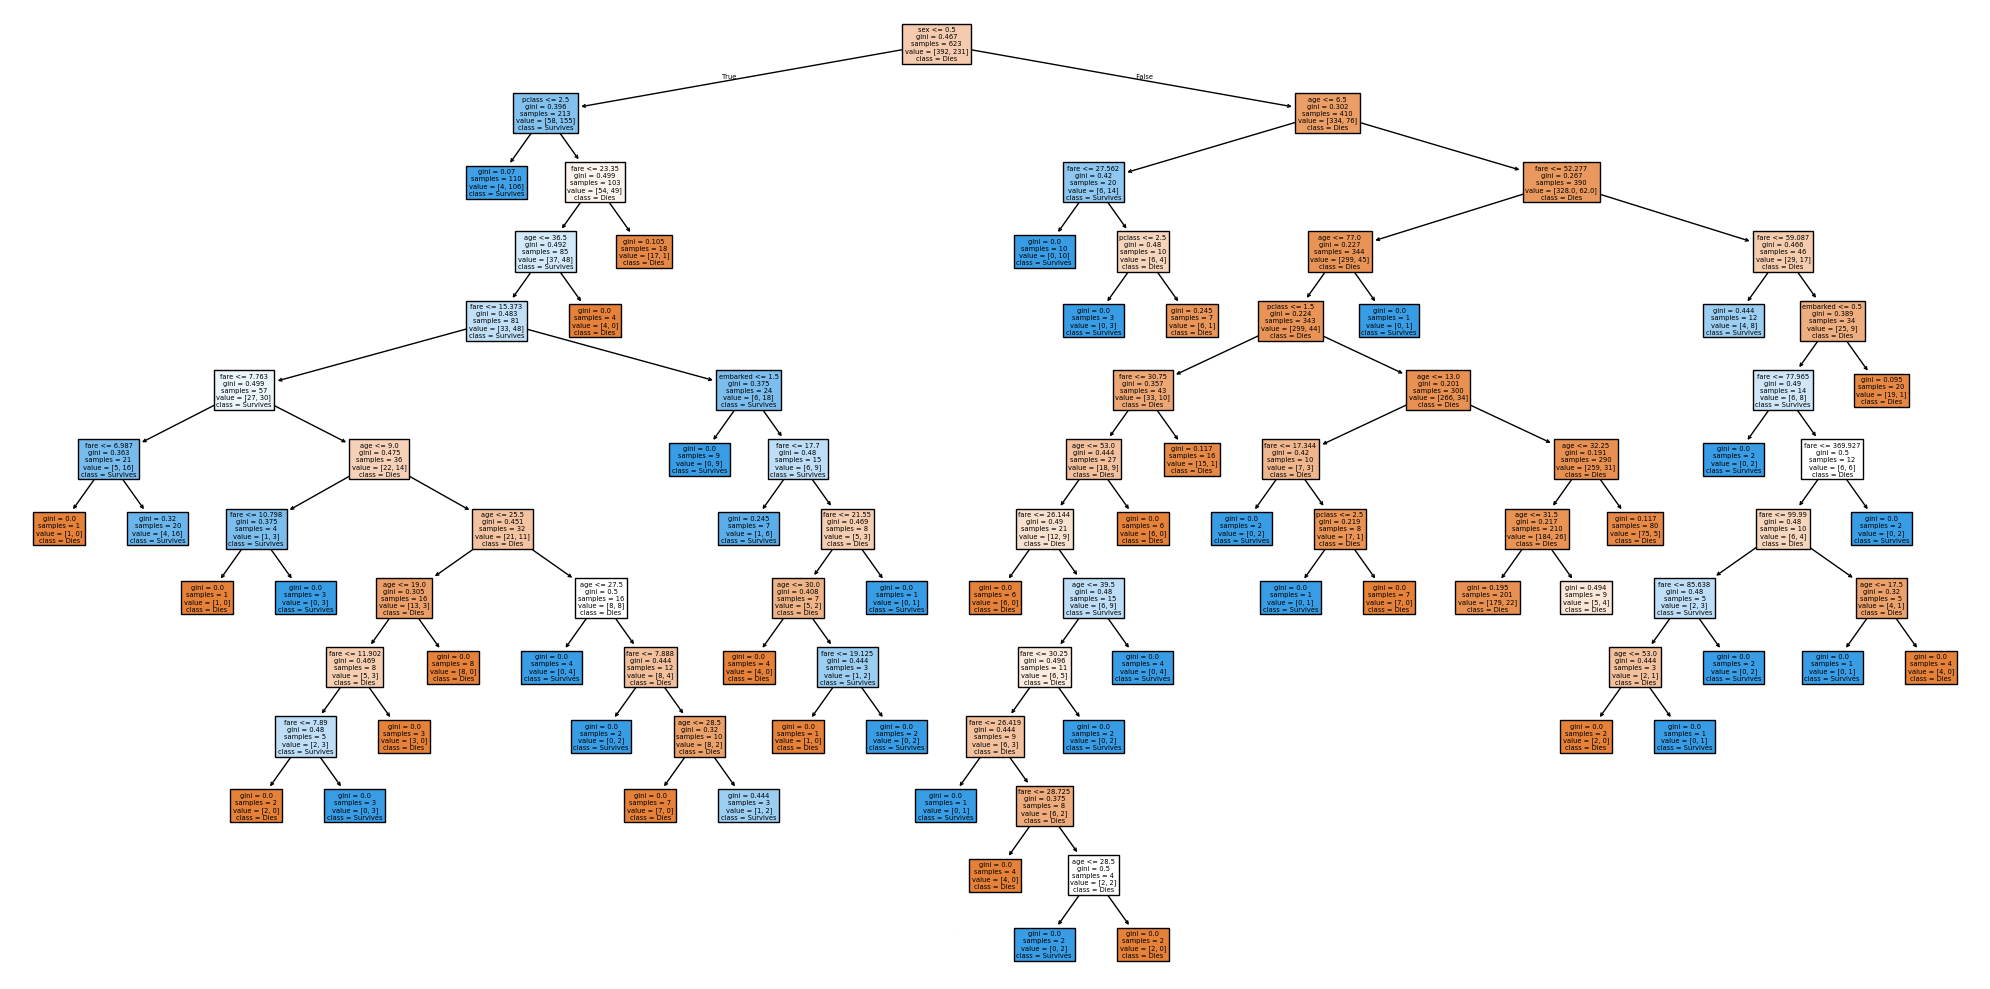

In [54]:
plt.figure(figsize=(20, 10))

plot_tree(
    best_model, 
    feature_names=X.columns,
    class_names=["Dies", "Survives"], # traget=0(died), 1(survived)
    filled=True,
)
        
plt.tight_layout()
        
plt.show()

In [56]:
print("Best model after post pruning: ", best_model.score(X_test, y_test))

Best model after post pruning:  0.8208955223880597


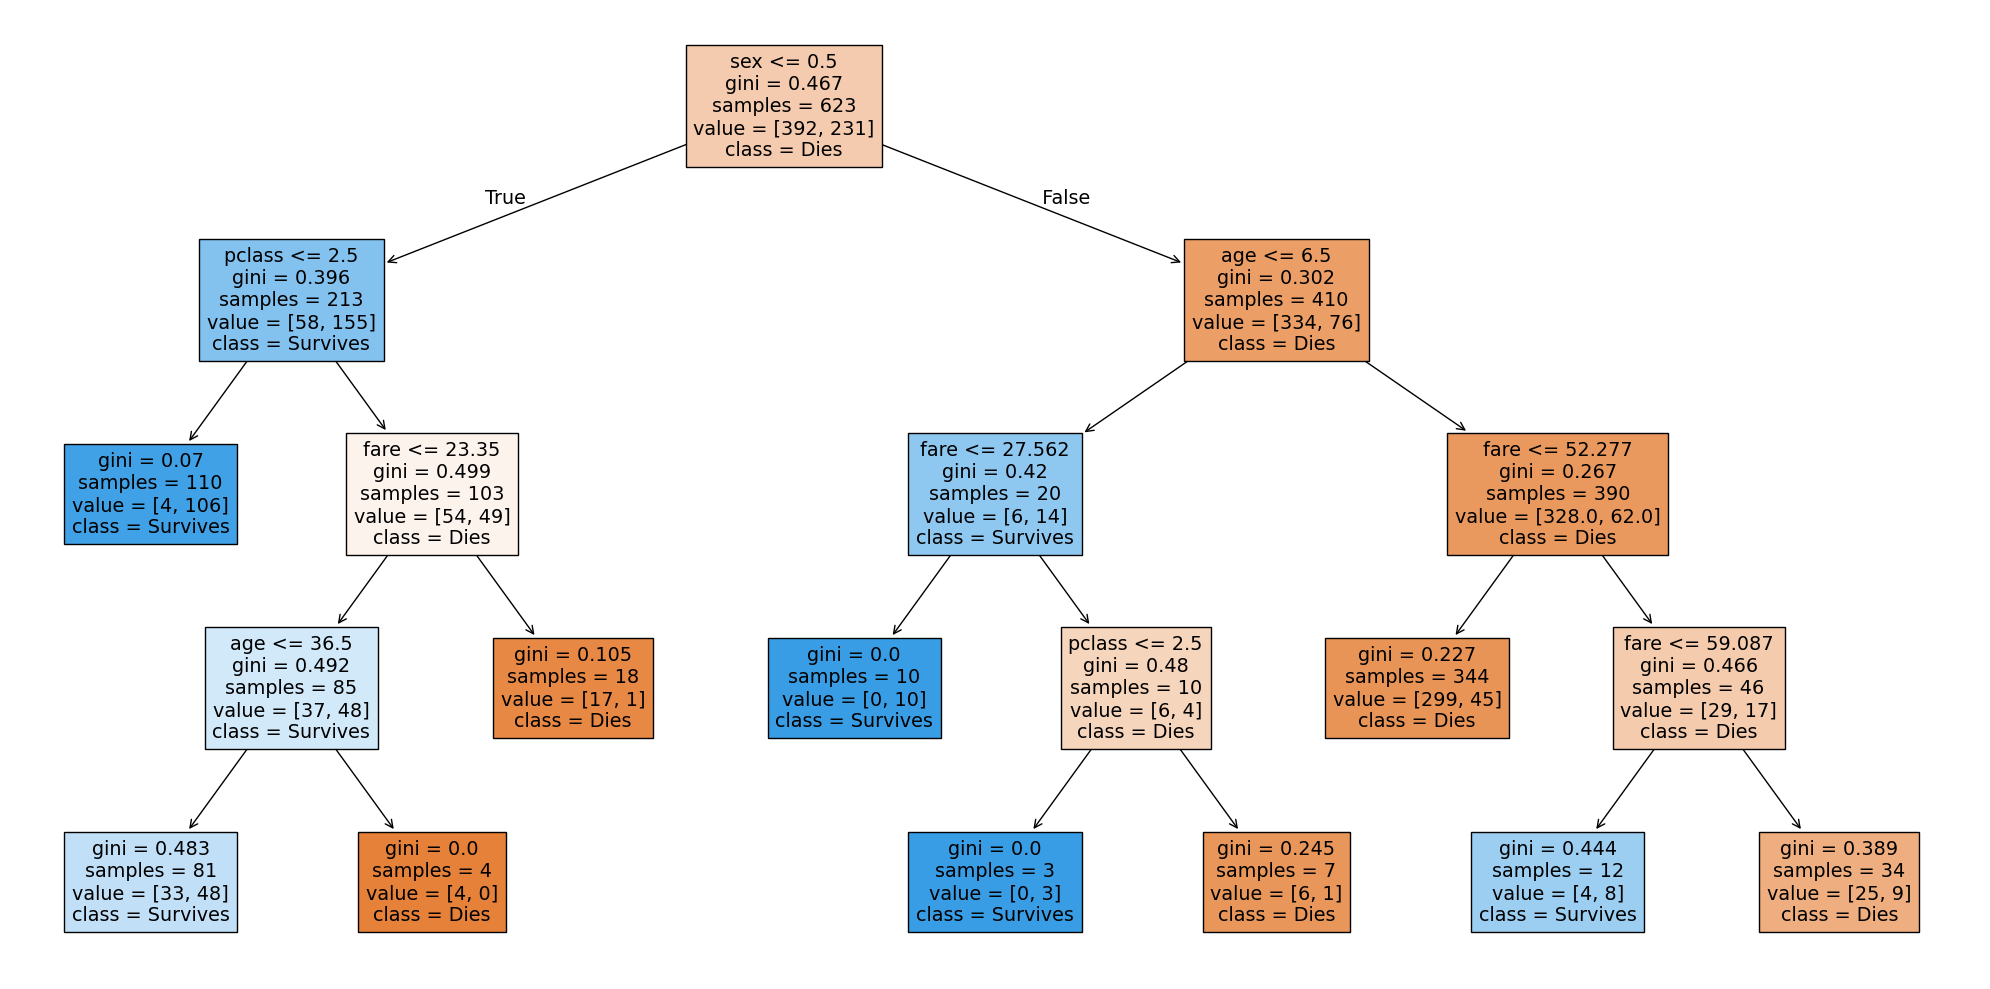

Best model after post pruning:  0.8246268656716418


In [57]:
# combination of both

best_model = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha, max_depth=4, max_leaf_nodes=10)
best_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))

plot_tree(
    best_model, 
    feature_names=X.columns,
    class_names=["Dies", "Survives"], # traget=0(died), 1(survived)
    filled=True,
)
        
plt.tight_layout()
        
plt.show()

print("Best model after post pruning: ", best_model.score(X_test, y_test))